In [1]:
import pandas as pd

In [9]:
base = pd.read_csv('sales_data_sample.csv', encoding='latin1')

In [12]:
base.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [13]:
base.shape

(2823, 25)

In [14]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [15]:
base.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [16]:
base['ORDERDATE'] = pd.to_datetime(base['ORDERDATE'])

In [17]:
base['ORDERDATE'].dtype

dtype('<M8[us]')

In [18]:
base[['SALES', 'PRODUCTLINE', 'COUNTRY', 'STATUS']].isnull().sum()

SALES          0
PRODUCTLINE    0
COUNTRY        0
STATUS         0
dtype: int64

In [19]:
vendas_produto = base.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
print(vendas_produto)

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


In [20]:
base['MES'] = base['ORDERDATE'].dt.month
vendas_mes = base.groupby('MES')['SALES'].sum().sort_values(ascending=False)
print(vendas_mes)

MES
11    2118885.67
10    1121215.22
5      923972.56
2      810441.90
1      785874.44
3      754501.39
4      669390.96
8      659310.57
12     634679.12
9      584724.27
7      514875.97
6      454756.78
Name: SALES, dtype: float64


In [21]:
vendas_pais = base.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(10)
print(vendas_pais)

COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
Name: SALES, dtype: float64


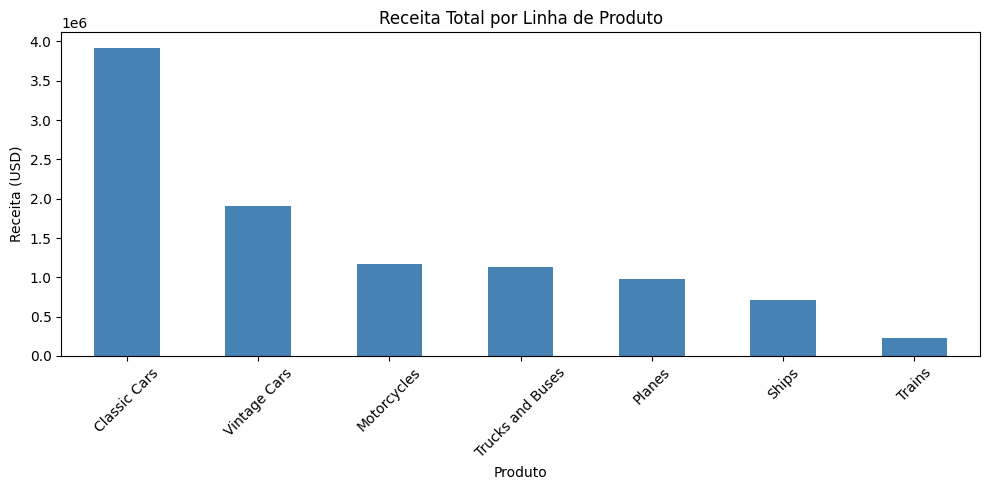

In [24]:
plt.figure(figsize=(10, 5))
vendas_produto.plot(kind='bar', color='steelblue')
plt.title('Receita Total por Linha de Produto')
plt.xlabel('Produto')
plt.ylabel('Receita (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

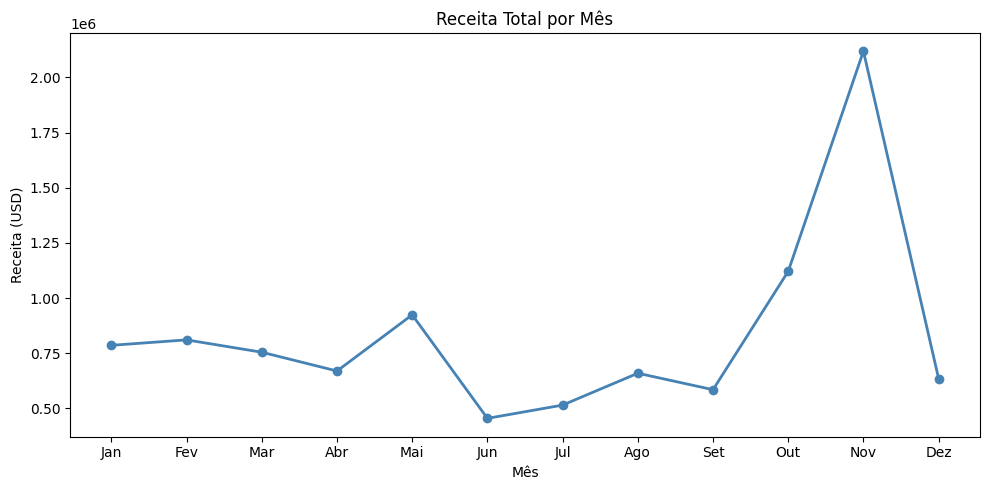

In [25]:
vendas_mes_ordenado = base.groupby('MES')['SALES'].sum()

plt.figure(figsize=(10, 5))
plt.plot(vendas_mes_ordenado.index, vendas_mes_ordenado.values, marker='o', color='steelblue', linewidth=2)
plt.title('Receita Total por Mês')
plt.xlabel('Mês')
plt.ylabel('Receita (USD)')
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
plt.tight_layout()
plt.show()

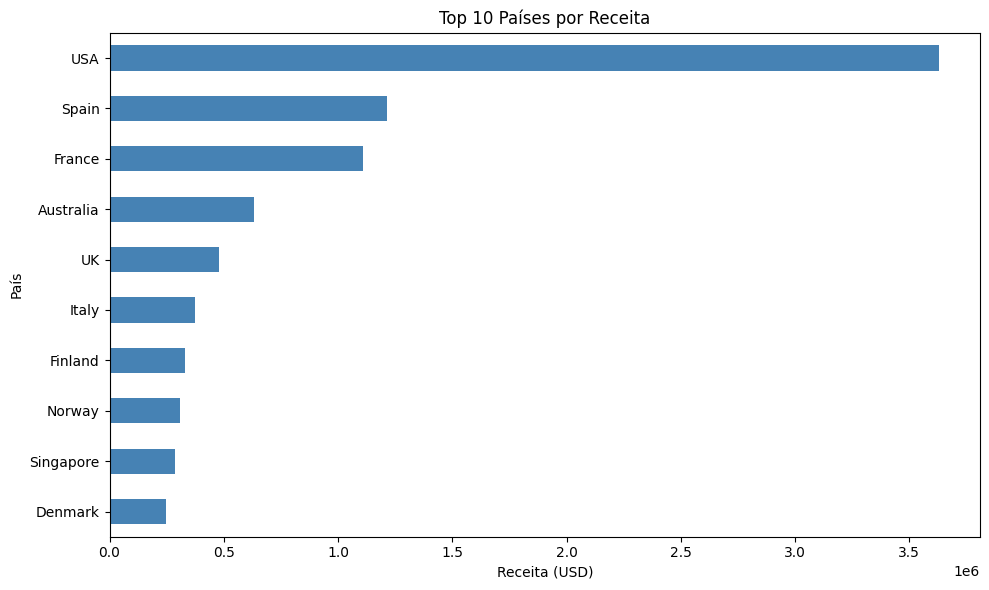

In [26]:
vendas_pais = base.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
vendas_pais.plot(kind='barh', color='steelblue')
plt.title('Top 10 Países por Receita')
plt.xlabel('Receita (USD)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

## Conclusões da Análise de Vendas

### Dados analisados
- 2.823 transacções entre 2003 e 2005
- 7 linhas de produto, 19 países

### Principais insights

**1. Produto mais rentável**
Classic Cars representa ~40% da receita total ($3.9M).
A empresa deve priorizar stock e marketing nesta categoria.

**2. Sazonalidade forte**
Novembro é o mês mais forte, com o dobro da média mensal.
Outubro-Novembro representa o pico de vendas anual.
Recomendação: reforçar stock e equipa de vendas no Q4.

**3. Mercado dominante**
Os EUA geram mais receita do que todos os outros países juntos.
Espanha e França são os mercados europeus mais relevantes.